Audio_To_Text

In [5]:
pip install SpeechRecognition

In [50]:
import speech_recognition as sr
import os

# Set the path to the FLAC converter if needed
sr.AudioFile.FLAC_converter = r"D:\Audio_Sub\flac-1.5.0-win\Win64\flac.exe"

def audio_to_text(audio_file):
    recognizer = sr.Recognizer()
    try:
        with sr.AudioFile(audio_file) as source:
            audio_data = recognizer.record(source)
        try:
            text = recognizer.recognize_google(audio_data)
            return text
        except sr.UnknownValueError:
            return "Speech recognition could not understand audio"
        except sr.RequestError as e:
            return f"Could not request results from speech recognition service; {e}"
    except FileNotFoundError:
        return f"Error: Audio file not found at {audio_file}"
    except Exception as e:
        return f"An unexpected error occurred: {e}"

#Testing
if __name__ == "__main__":
    audio_file = "OSR_us_000_0010_8k.wav"
    result = audio_to_text(audio_file)
    print("Transcription:", result)

Transcription: the birds canoe slid on the smooth planks glue the sheet to the dark blue background it is easy to tell the depth of a well these days a chicken leg is a rare dish rice is often served in round Bowls the juice of lemons makes fine punch the box was thrown beside the park truck the Hogs are fed chopped corn and garbage 4 hours of study work face does a large size in stockings is hard to sell


Feature Extraction

In [51]:
import numpy as np
import librosa

In [52]:
def extract_pitch_silence(audio_file):
    try:
        y, sr_val = librosa.load(audio_file, sr=None)
        f0, voiced_flag, voiced_probs = librosa.pyin(y,fmin=librosa.note_to_hz('C2'), fmax=librosa.note_to_hz('C7'))
        pitch_variability = np.nanstd(f0[voiced_flag]) if np.any(voiced_flag) else 0.0
        hop_length = 512
        frame_length = 1024
        energy = np.array([sum(abs(y[i:i+frame_length]**2))
            for i in range(0, len(y) - frame_length + 1, hop_length)])
        if len(energy) == 0:
             return {"pitch_variability": pitch_variability, "pause_ratio": 0.0}
        silence_threshold = np.median(energy) * 0.1
        pause_frames = np.sum(energy < silence_threshold)
        total_frames = len(energy)
        pause_ratio = pause_frames / total_frames if total_frames > 0 else 0.0
        return {"pitch_variability": float(pitch_variability) if not np.isnan(pitch_variability) else 0.0,
                "pause_ratio": float(pause_ratio)}
    except Exception as e:
        print(f"Error processing {audio_file} in extract_pitch_silence: {e}")
        return {"pitch_variability": 0.0, "pause_ratio": 0.0}

In [53]:
import re

def count_hesitations(text):
    text = text.lower()
    hesitation_markers = re.findall(
        r'\b(uh|um|er|ah|uhm|hmm|huh|mmm|eh|like|you know|i mean|so|well|huh)\b',
        text
    )
    return len(hesitation_markers)

In [54]:
def hesitation_freq(hesitation_count, words_len):
  hesitation_frequency = hesitation_count / words_len if words_len > 0 else 0
  return hesitation_frequency

In [55]:
def compare_with_reference(transcript, reference_words):
    transcript_words = transcript.lower().split()
    mismatches = sum(1 for word in reference_words if word.lower() not in transcript_words)
    return mismatches

In [56]:
def get_audio_duration(audio_file):
    try:
        duration = librosa.get_duration(path=audio_file)
        return duration
    except Exception as e:
        print(f"Error getting duration for {audio_file}: {e}")
        return 0.0

In [57]:
def calculate_speech_rate(transcript, audio_duration):
    num_words = len(transcript.split())
    speech_rate = (num_words / audio_duration) * 60 if audio_duration > 0 else 0
    return {"num_words": num_words, "speech_rate": speech_rate}

Making DataFrame

In [58]:
import pandas as pd
def making_data_frame(audio_file, reference_words):
    transcript = audio_to_text(audio_file)
    pitch_pause = extract_pitch_silence(audio_file)
    hesitation_count = count_hesitations(transcript)
    hesitation_frequency = hesitation_freq(hesitation_count, len(transcript.split()))
    audio_duration = get_audio_duration(audio_file)
    recall_issues = compare_with_reference(transcript, reference_words)
    num_speech = calculate_speech_rate(transcript, audio_duration)
    features = {
        "transcript": transcript,
        "pitch_variability": pitch_pause['pitch_variability'],
        "pause_ratio": pitch_pause['pause_ratio'],
        "hesitation_count": hesitation_count,
        "hesitation_frequency": hesitation_frequency,
        "recall_issues": recall_issues,
        "words_len": num_speech['num_words'],
        "speech_rate_wpm": num_speech['speech_rate']
    }
    return pd.DataFrame([features])

Anamoly Detection and Score

In [59]:
from sklearn.ensemble import IsolationForest

def detect_anomalies(df):
    numeric_df = df.select_dtypes(include='number')
    iso_forest = IsolationForest(contamination='auto', random_state=42)
    df['anomaly_label'] = iso_forest.fit_predict(numeric_df)
    df['anomaly_score'] = iso_forest.decision_function(numeric_df)
    return df

In [60]:
audio_data = [
    {
        "audio_file": os.path.join(os.getcwd(), "OSR_us_000_0010_8k.wav"),
        "reference_words": ["the", "birch", "canoe", "slid", "on", "smooth", "planks"]
    },
    {
        "audio_file": os.path.join(os.getcwd(), "OSR_us_000_0011_8k.wav"),
        "reference_words": ["help", "the", "next", "party", "plan", "trip"]
    },
    {
        "audio_file": os.path.join(os.getcwd(), "OSR_us_000_0012_8k.wav"),
        "reference_words": ["the", "meal", "was", "served", "in", "a", "large", "pot"]
    },
    {
        "audio_file": os.path.join(os.getcwd(), "OSR_us_000_0013_8k.wav"),
        "reference_words": ["lick", "the", "pot", "scrape", "the", "inside"]
    },
    {
        "audio_file": os.path.join(os.getcwd(), "OSR_us_000_0014_8k.wav"),
        "reference_words": ["view", "the", "peak", "or", "the", "valley"]
    },
    {
        "audio_file": os.path.join(os.getcwd(), "OSR_us_000_0015_8k.wav"),
        "reference_words": ["the", "small", "pup", "gnawed", "a", "large", "bone"]
    },
    {
        "audio_file": os.path.join(os.getcwd(), "OSR_us_000_0016_8k.wav"),
        "reference_words": ["the", "coast", "guard", "watched", "the", "fog"]
    },
]

In [61]:
final_df = pd.DataFrame()

for item in audio_data:
    row_df = making_data_frame(item["audio_file"], item["reference_words"])
    final_df = pd.concat([final_df, row_df], ignore_index=True)
final_df

,transcript,pitch_variability,pause_ratio,hesitation_count,hesitation_frequency,recall_issues,words_len,speech_rate_wpm
0,the birds canoe slid on the smooth planks glue...,128.838634,0.125954,1,0.012346,1,81,144.543376
1,the boy was there when the sun rose a rod is u...,98.274094,0.211350,0,0.000000,4,78,142.749297
2,does small pup not a hole in the sock the fish...,103.906973,0.299228,0,0.000000,4,69,124.442507
3,what's the low to your left shoulder take the ...,154.057468,0.043393,0,0.000000,4,73,134.591673
4,a King rule the state in the early days the sh...,128.114854,0.022680,0,0.000000,4,73,140.735326
5,the first can you slid on the smooth planks gl...,235.408394,0.000000,1,0.012346,4,81,117.321875
6,the boy was there when the sun rose a rod is u...,153.097511,0.000000,1,0.012658,4,79,134.932214


In [62]:
#Using K-Means
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
features = final_df[["pitch_variability", "pause_ratio", "hesitation_count", "recall_issues", "speech_rate_wpm"]]
scaled_features = scaler.fit_transform(features)

In [63]:
cluster_df = pd.DataFrame()
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_df["cluster"] = kmeans.fit_predict(scaled_features)

In [72]:
cluster_df

,cluster
0,1
1,0
2,0
3,1
4,1
5,1
6,1


In [66]:
detect_anomalies(final_df)

,transcript,pitch_variability,pause_ratio,hesitation_count,hesitation_frequency,recall_issues,words_len,speech_rate_wpm,anomaly_label,anomaly_score
0,the birds canoe slid on the smooth planks glue...,128.838634,0.125954,1,0.012346,1,81,144.543376,-1,-0.061310
1,the boy was there when the sun rose a rod is u...,98.274094,0.211350,0,0.000000,4,78,142.749297,1,0.025747
2,does small pup not a hole in the sock the fish...,103.906973,0.299228,0,0.000000,4,69,124.442507,-1,-0.044857
3,what's the low to your left shoulder take the ...,154.057468,0.043393,0,0.000000,4,73,134.591673,1,0.071176
4,a King rule the state in the early days the sh...,128.114854,0.022680,0,0.000000,4,73,140.735326,1,0.082252
5,the first can you slid on the smooth planks gl...,235.408394,0.000000,1,0.012346,4,81,117.321875,-1,-0.044459
6,the boy was there when the sun rose a rod is u...,153.097511,0.000000,1,0.012658,4,79,134.932214,1,0.032789


Plotting

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

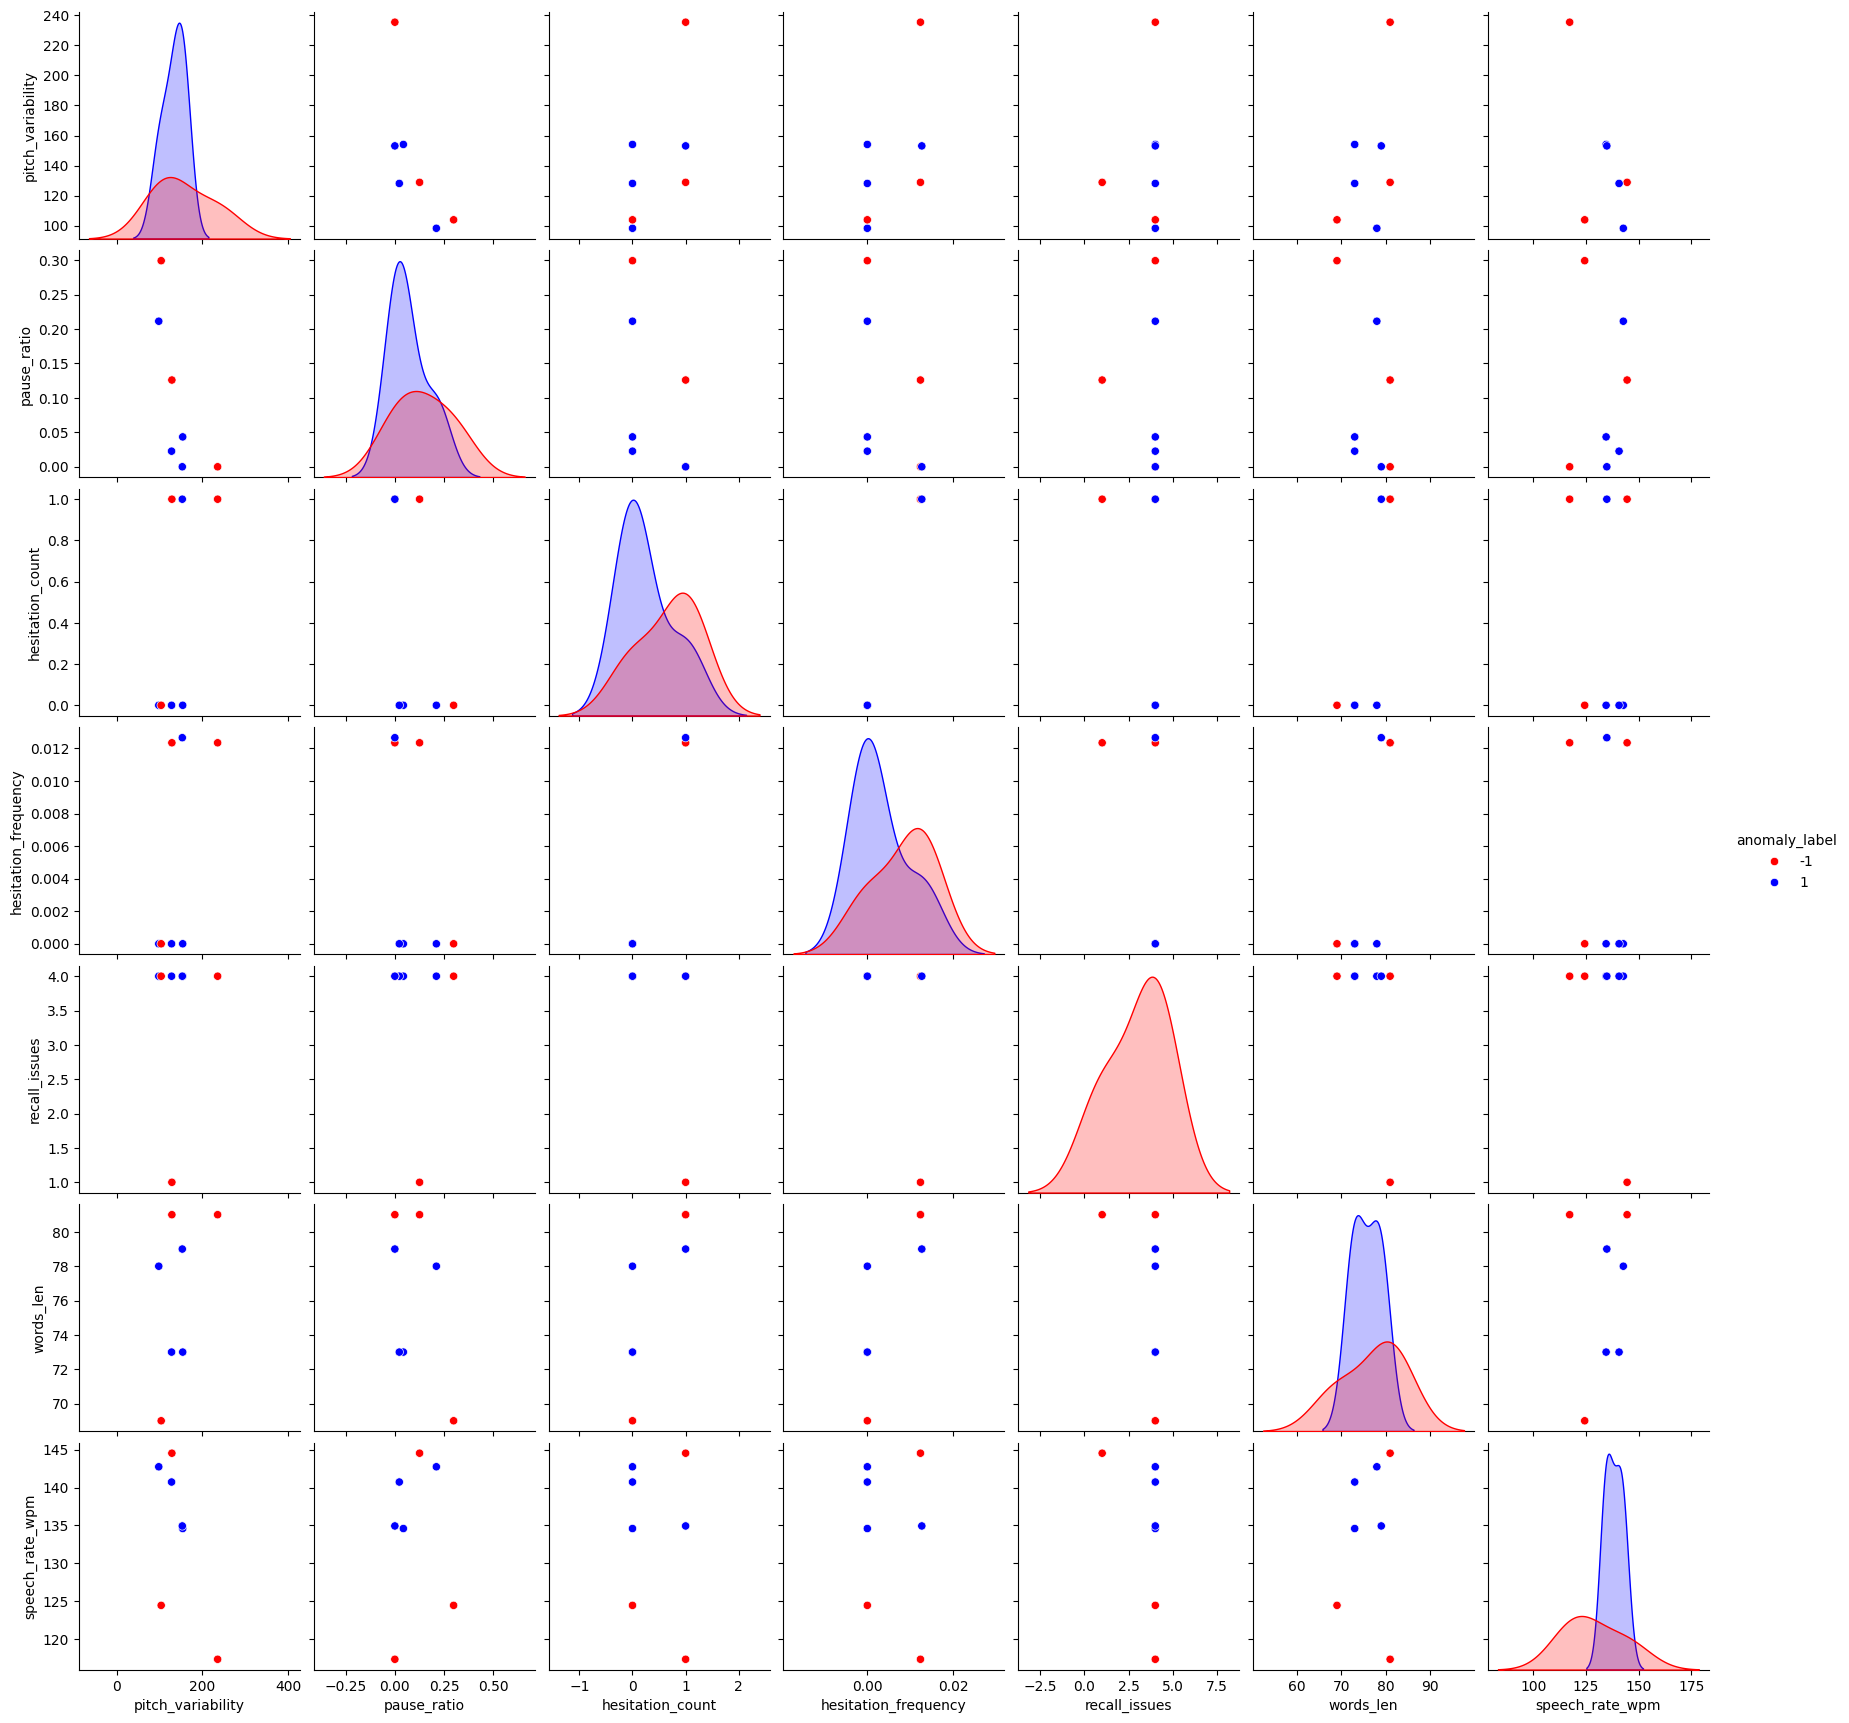

In [67]:
features = [
    'pitch_variability', 'pause_ratio', 'hesitation_count',
    'hesitation_frequency', 'recall_issues', 'words_len', 'speech_rate_wpm'
]
sns.pairplot(final_df, hue='anomaly_label', vars=features, palette={1: 'blue', -1: 'red'})
plt.show()

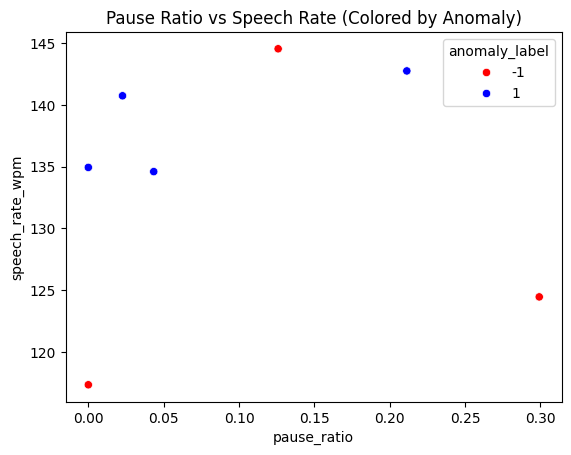

In [69]:
sns.scatterplot(data=final_df, x='pause_ratio', y='speech_rate_wpm', hue='anomaly_label', palette={1: 'blue', -1: 'red'})
plt.title('Pause Ratio vs Speech Rate (Colored by Anomaly)')
plt.show()

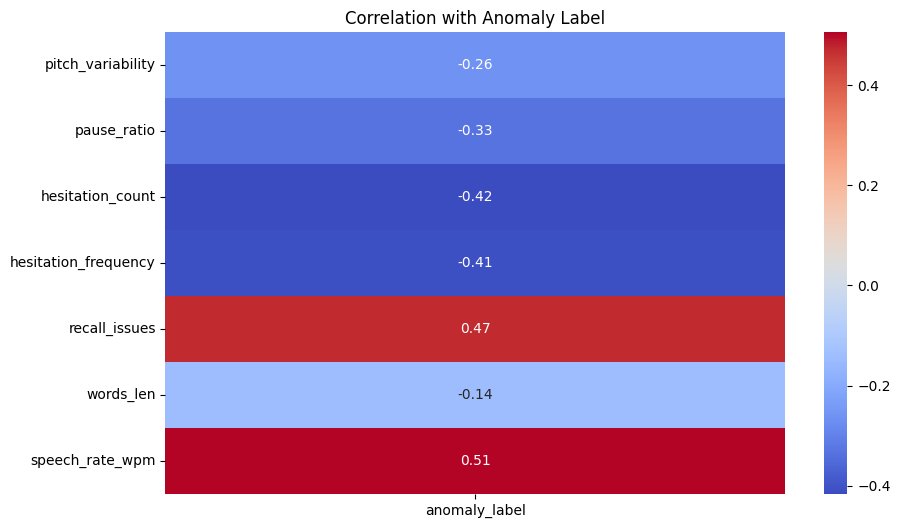

In [70]:
corr_columns = [
    'pitch_variability', 'pause_ratio', 'hesitation_count',
    'hesitation_frequency', 'recall_issues', 'words_len', 'speech_rate_wpm', 'anomaly_label'
]
corr_matrix = final_df[corr_columns].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix[['anomaly_label']].drop('anomaly_label'), annot=True, cmap='coolwarm')
plt.title('Correlation with Anomaly Label')
plt.show()

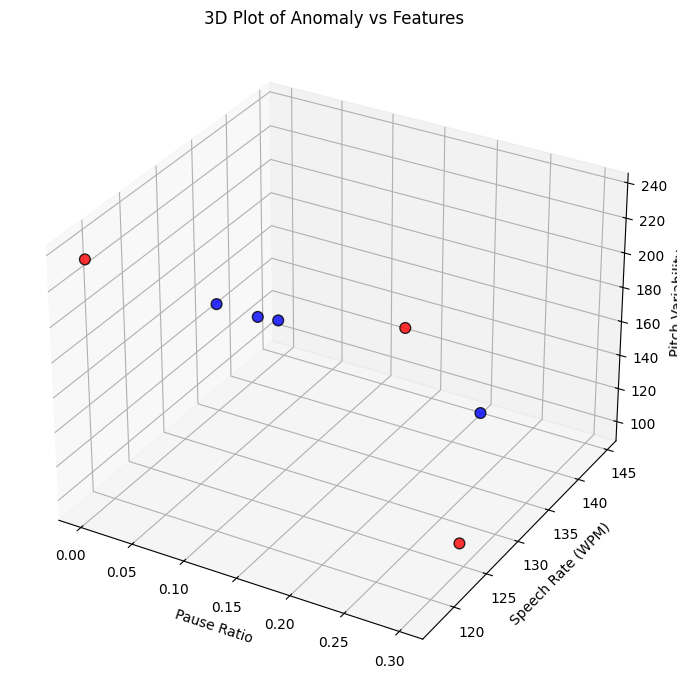

In [71]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Ensure anomaly_label is integer (0 or 1)
final_df['anomaly_label'] = final_df['anomaly_label'].astype(int)

# Define features to use
features_to_plot = ['pause_ratio', 'speech_rate_wpm', 'pitch_variability', 'anomaly_label']
plot_df = final_df[features_to_plot]

# Map anomaly_label to colors
colors = plot_df['anomaly_label'].map({1: 'blue', -1: 'red'})

# Plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    plot_df['pause_ratio'],
    plot_df['speech_rate_wpm'],
    plot_df['pitch_variability'],
    c=colors,
    s=60,
    alpha=0.8,
    edgecolors='k'
)

ax.set_xlabel('Pause Ratio')
ax.set_ylabel('Speech Rate (WPM)')
ax.set_zlabel('Pitch Variability')
ax.set_title('3D Plot of Anomaly vs Features')
ax.grid(True)

plt.tight_layout()
plt.show()


Report

Insightful Features
Among the engineered features, the following showed strong correlation with anomalies in speech:

Pitch Variability: Anomalous samples often exhibited unusually high or low pitch variability, reflecting emotional instability or monotone delivery.

Pause Ratio: Elevated pause ratios were frequent in anomaly-labeled data, possibly indicating hesitation, cognitive load, or disfluency.

Hesitation Frequency: Frequent usage of hesitation markers ("um", "uh", "ah", etc.) served as a strong indicator of disorganized or uncertain speech.

Speech Rate (WPM): Both abnormally fast and slow speech rates appeared in anomalous samples, indicating issues with fluency or cognitive processing.

Recall Issues: Detected by comparing transcripts to reference phrases, recall issues gave direct insight into memory and comprehension.

Unsupervised Anomaly Detection:

Anomaly scores were generated using statistical feature behavior, and thresholds were applied to label outliers.

This approach was chosen due to limited labeled data and the desire to detect subtle speech deviations without hardcoded rules.

Visualization:

Pair plots and 3D scatter plots with color-coded anomaly labels provided intuitive ways to inspect feature interrelations.

Heatmaps helped assess correlations and redundancy among features.



To move toward a clinically viable system, the following steps are essential:

Larger & Labeled Dataset:

Collect and validate speech data from individuals with known cognitive conditions (e.g., early dementia, depression).

Include demographics to generalize across populations.

Model Upgrade:

Incorporate supervised learning (e.g., Random Forest, SVM, or Gradient Boosting) once labeled data is available.

Evaluate models using clinical metrics like precision, recall, and F1-score—not just accuracy.

Feature Enhancement:

Add prosodic features (e.g., intonation, energy, jitter).

Use automatic speech alignment to detect word-level delays and mispronunciations.

Cross-validation with Clinical Experts:

Work with psychologists or neurologists to validate if the features reflect clinically meaningful behavior.

Real-time Integration:

Develop a lightweight system that could work in real-time during assessments or therapy sessions.

